In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder



In [71]:
url = 'https://raw.githubusercontent.com/niksonlaurentino/SCTECH_Projeto_Avaliativo_M_1/fase/eda/dataset/credit_risk_dataset.csv'

In [72]:
df = pd.read_csv(url)

# Fase 1: Análise Exploratória de Dados (EDA)
# Descritiva e Estatística: tamanho total da base (linhas e colunas)

In [73]:
df.shape

(32581, 12)

# Tipos de dados de cada variável 

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


# Sumário estatístico descritivo (médias, mínimos, máximos e quartis via .describe())

In [75]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


# Frequência de aparecimento de valores CATEGÓRICOS e NUMÉRICOS

In [76]:
cat_cols = df.select_dtypes(include='str').columns
num_cols = df.select_dtypes(include='number').columns

In [77]:
print(f'{50*'='} COLUNAS CATEGORICAS {50*'='}')
for column in cat_cols:
    print(f'COLUNA: {df[column].value_counts()}')
    print(f'{50*'-'}')

print(f'{50*'='} COLUNAS NUMERICAS {50*'='}')
for column in num_cols:
    print(f'COLUNA: {df[column].value_counts()}')
    print(f'{50*'-'}')

================================================== COLUNAS CATEGORICAS ==================================================
COLUNA: person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64
--------------------------------------------------
COLUNA: loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64
--------------------------------------------------
COLUNA: loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64
--------------------------------------------------
COLUNA: cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64
--------------------------------------------------
================================================== COLUNAS NUMERICAS ==================================================
COLUNA: person_age
2

# Análise Visual: 
# Histograma de distribuição de idades/valores

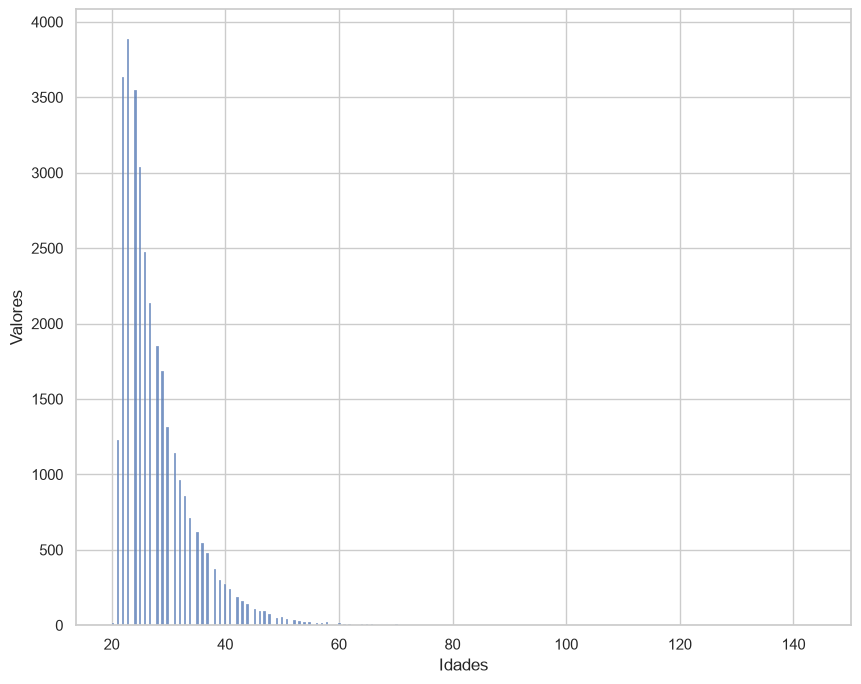

In [78]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=[10,8])
sns.histplot(df, x='person_age')
plt.ylabel('Valores')
plt.xlabel('Idades')
plt.show()

# Gráfico de barras provando o desbalanceamento da variável alvo 

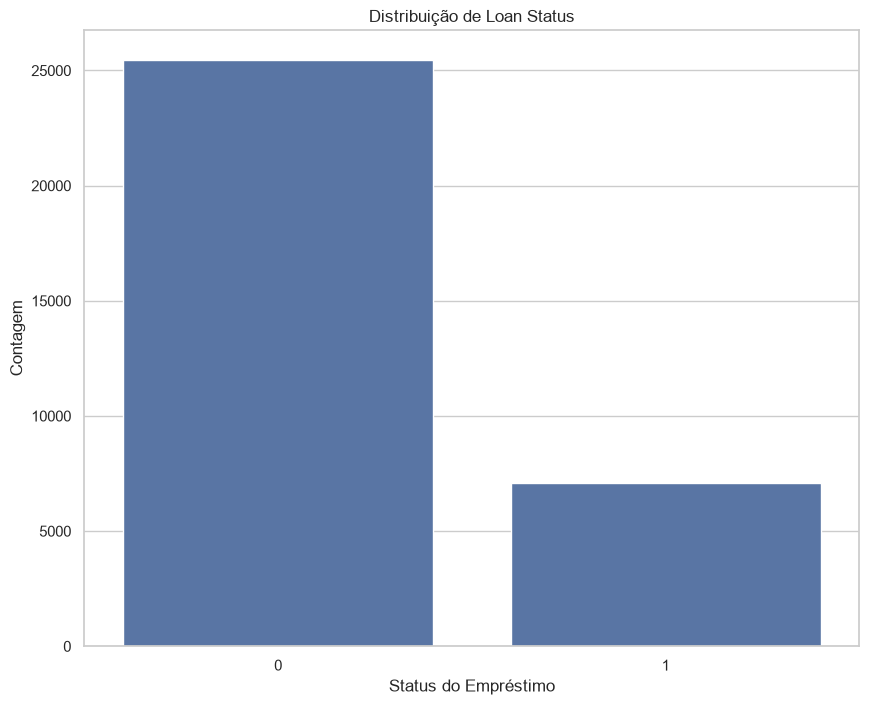

In [79]:
plt.figure(figsize=[10, 8])
sns.countplot(data=df, x='loan_status')
plt.title('Distribuição de Loan Status')
plt.xlabel('Status do Empréstimo')
plt.ylabel('Contagem')
plt.show()

# Mapa de calor de correlação de Pearson das variáveis numéricas

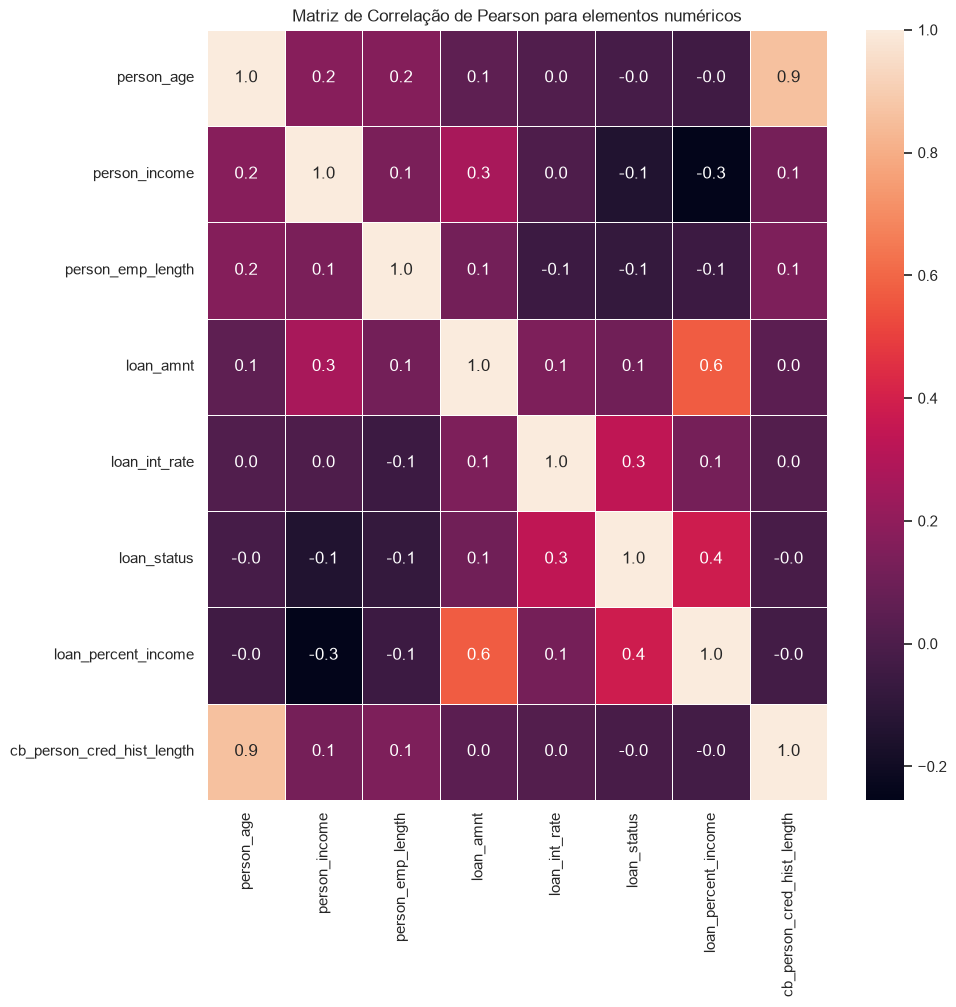

In [80]:
num_cols = df.select_dtypes(include='number')
plt.figure(figsize=[10,10])
sns.heatmap(num_cols.corr(), annot=True, fmt='.1f', linewidth=.5)
plt.title('Matriz de Correlação de Pearson para elementos numéricos')
plt.show()

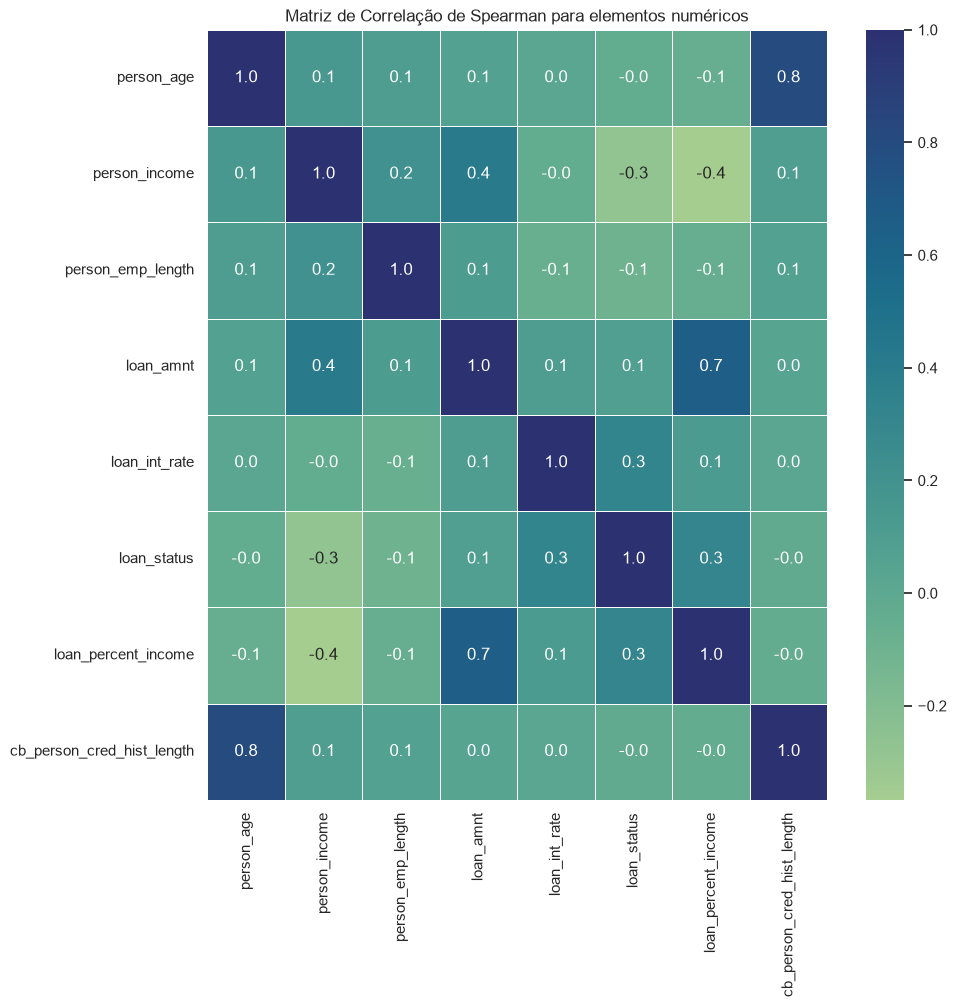

In [81]:
plt.figure(figsize=[10,10])
sns.heatmap(num_cols.corr('spearman'), annot=True, fmt='.1f', linewidth=.5,  cmap="crest")
plt.title('Matriz de Correlação de Spearman para elementos numéricos')
plt.show()

# TOMADA DE DECISÃO
O dataframe é composto por 32.581 linhas e 12 colunas, das quais 8 são numéricas e 4 categóricas. Através do método describe(), constatamos que a variável numérica idade (person_age) não apresenta valores mínimos negativos, o que confirma a consistência dos dados. Observa-se também uma forte disparidade entre a média e a mediana na variável de rendimento (person_income), indicando a presença de diversos outliers. Quanto ao mapa de calor com as correlações de Pearson e Spearman, que medem a associação entre as variáveis, vale destacar que coeficientes acima de 0,75 ou abaixo de -0,75 devem ser analisados com cautela para evitar multicolinearidade. Como a variável person_age possui uma correlação alta de 0,90 com cb_person_cred_hist_length, uma abordagem recomendada é a remoção de uma delas quando o algoritmo for KNN, mas se o modelo for random forest não será preciso excluir essa coluna, tão pouco padronizar os valores numéricos.
* OBS: Faremos a imputação por mediana após o split para evitar vazamento de dados (data leakage).

# Fase 2: Tratamento e Limpeza (Data Prep)

# Dropando as linhas duplicadas

In [82]:
df = df.drop_duplicates()

# Valores Nulos

Podemos constatar a presença de nulos para as colunas da seguinte forma:
* person_emp_length             2.74% de nulos com um total de 887
* loan_int_rate                 9.55% de nulos com um total de 3095

Baseado no estudo anterior, podemos fazer a imputação estatística por mediana, pois ela é menos suscetível a presença de outliers, pois um dos algoritmos que usaremos será o KNN que é sensível a distâncias.


In [83]:
round((df.isnull().sum() / df.shape[0]) * 100,2), df.isnull().sum()

(person_age                    0.00
 person_income                 0.00
 person_home_ownership         0.00
 person_emp_length             2.74
 loan_intent                   0.00
 loan_grade                    0.00
 loan_amnt                     0.00
 loan_int_rate                 9.55
 loan_status                   0.00
 loan_percent_income           0.00
 cb_person_default_on_file     0.00
 cb_person_cred_hist_length    0.00
 dtype: float64,
 person_age                       0
 person_income                    0
 person_home_ownership            0
 person_emp_length              887
 loan_intent                      0
 loan_grade                       0
 loan_amnt                        0
 loan_int_rate                 3095
 loan_status                      0
 loan_percent_income              0
 cb_person_default_on_file        0
 cb_person_cred_hist_length       0
 dtype: int64)

# Tratamento de Outliers
# Boxplot para Evidenciar Outliers
Nota-se que após o bigode superior temos várias ocorrências de valores. O limite do bigode superior é calculado pela fórmula estatística Q3 + 1,5 x (IQR).

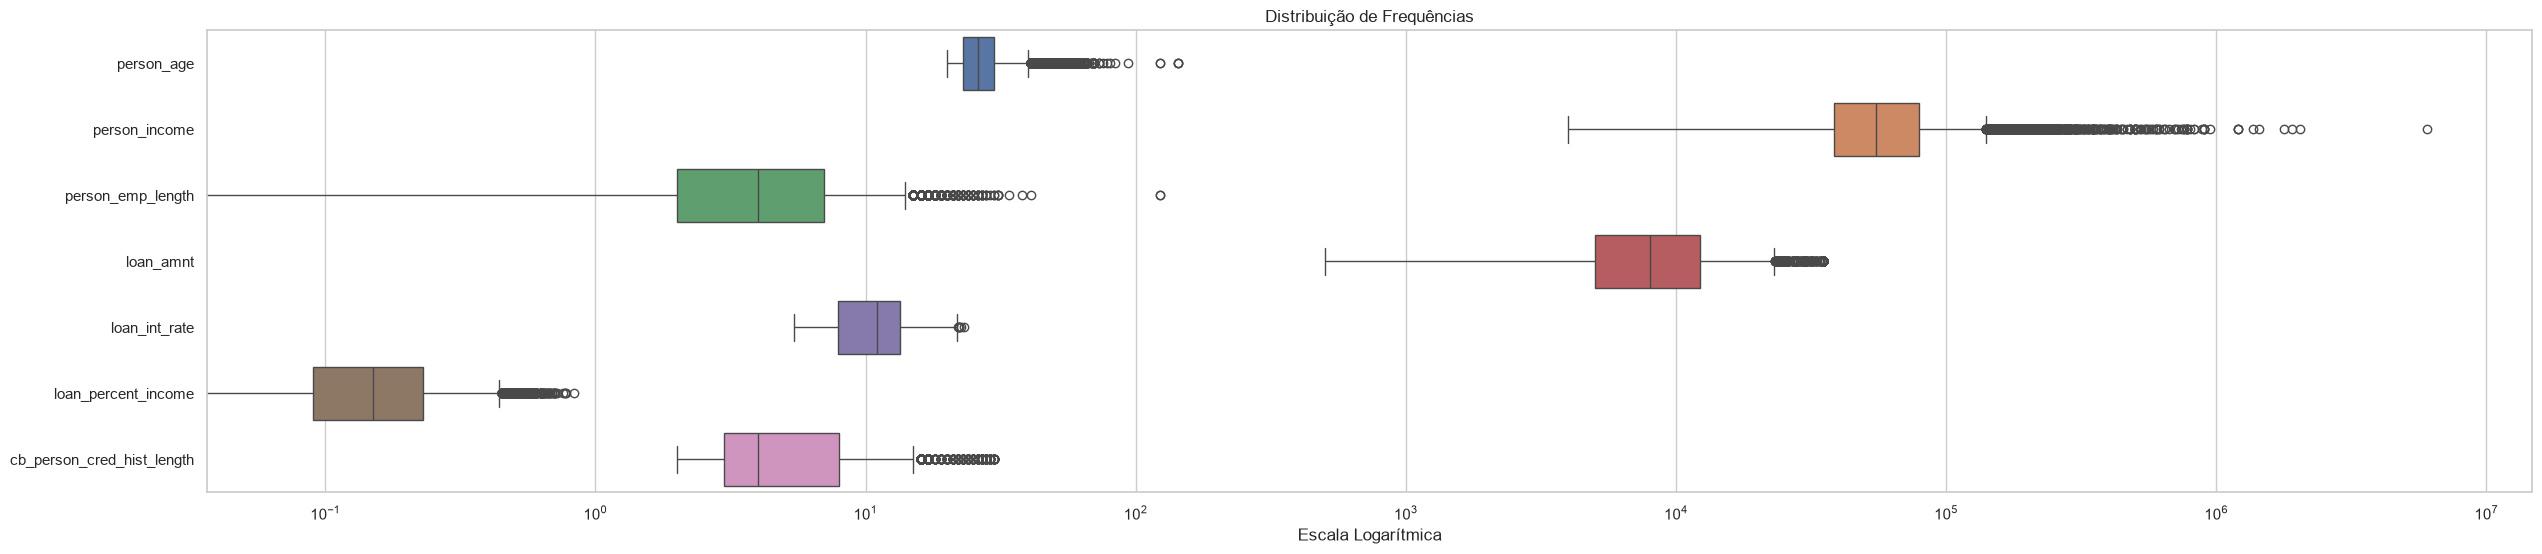

In [84]:
plt.figure(figsize=[30,6])
sns.boxplot(data=df[['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length']], orient='h')
plt.xscale('log') #a escala tem que ser em logarítmico, pois senão os valores ficam empilhados
plt.title('Distribuição de Frequências')
plt.xlabel('Escala Logarítmica')
plt.show()

# Análise de Outliers
Vemos em quase todas as variáveis a presença massiva de outliers. Como vamos trabalhar com dois algoritmos, vamos usar um dataframe voltado para KNN removendo outliers e outro dataframe sem a remoção de outliers para Random Forest. 

# Fase 3: Feature Engineering (Coluna Calculada)
Como as colunas loan_amnt e person_income não tem valores nulos como vimos anteriormente, podemos utilizá-las para criar uma nova coluna sem problemas.

In [85]:
df['comprometimento_renda']  = round((df['loan_amnt'] / df['person_income']) * 100,2) # coloquei o round para ficar apenas dois números após a vírgula
#Montamos duas copias de dataset para tratamentos dedicados para cada algoritmo
df_pre_processing = df.copy()

* O df_pre_processing servirá de bifurcação para iniciarmos dois tratamentos distintos: um para KNN e outro para Random Forest

# Fase 4: Separação, Balanceamento e Escalonamento Seguro

In [86]:
y = df_pre_processing['loan_status']
x = df_pre_processing.drop(columns=['loan_status'])
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)


# IMPUTAÇÃO PELA MEDIANA (Evita vazamento de dados)
Aqui temos a bifurcação de processos, ou seja, para evitar repetição desnecessária no código usaremos a imputação por mediana também para random forest

In [87]:
num_cols_preprocessing = x_train.select_dtypes(include='number').columns

imputer = SimpleImputer(strategy='median')
x_train[num_cols_preprocessing] = imputer.fit_transform(x_train[num_cols_preprocessing])
x_test[num_cols_preprocessing] = imputer.transform(x_test[num_cols_preprocessing])

# Utilização de Ordinal Encoder para Colocar o loan_grade por Peso
* OBSERVAÇÃO: Variáveis Categóricas do Tipo Ordinais tem relação de peso entre si e devem ser submetidas ao ordinal encoder diferentes de Variáveis Categóricas do tipo Nominais que não tem ordem entre si. 

In [88]:
cat_cols_preprocessing = x_train.select_dtypes(include='str').columns

# 1. Define a ordem lógica exata das categorias (da menor para a maior)
ordem_grade = [['A', 'B', 'C', 'D', 'E', 'F', 'G']]

# 2. Instancia o encoder passando a ordem
encoder_grade = OrdinalEncoder(categories=ordem_grade)

x_train['loan_grade'] = encoder_grade.fit_transform(x_train[['loan_grade']])
x_test['loan_grade'] = encoder_grade.transform(x_test[['loan_grade']])


# CORTE DE OUTLIERS PARA KNN

In [89]:
x_train_knn = x_train.copy()

for col in num_cols_preprocessing:
    # Calcula Q1 e Q3 com base nos dados do treino já imputado
    Q1 = x_train[col].quantile(0.25) 
    Q3 = x_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Corta diretamente na variável X_train_clean (acumula os cortes)
    x_train_knn = x_train_knn[(x_train_knn[col] >= limite_inferior) & (x_train_knn[col] <= limite_superior)]

# 3. Sincroniza o y_train usando os índices que sobraram no X_train_clean
y_train_knn = y_train.loc[x_train_knn.index]